In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lstsq
from scipy import stats
import seaborn as sns

from scipy import interpolate


from utils import *


In [56]:
df = process_roi_txt_to_excel("Poplar_02_L1_M3_second_Branch.txt", "Poplar_02_L1_M3_second_Branch.xlsx")
df = df.iloc[1:]

In [57]:
xi=list(df.columns)
xi = xi [0:5]
t=df.index.to_numpy()

data_cor=df[xi].to_numpy(dtype=float)

data_unc=df[xi].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

steps=len(data_cor)

d_xi=[]

for i in range(1,len(xi)):
     d_xi.append(float(xi[i])-float(xi[i-1]))

In [58]:
xi

[0.0,
 14.28070634400066,
 28.32597296637153,
 42.475230827537715,
 56.6138566537035]

In [59]:
df

,0.000000,14.280706,28.325973,42.475231,56.613857,70.769561,84.723037,98.946101
5.0,32.080767,36.107413,37.693075,39.988128,43.354631,48.971348,66.730117,127.080981
10.0,34.761057,34.202865,42.103758,41.989007,49.533176,53.843378,65.425000,107.681399
15.0,44.667706,44.774594,38.998107,49.831303,46.887787,58.904924,67.323272,95.307876
20.0,48.830438,46.526786,53.750858,59.471679,60.199100,61.051742,87.646399,106.980832
25.0,64.083130,55.779166,72.058317,65.716005,71.501704,88.316369,96.599606,146.611826
30.0,94.971397,112.406764,100.775196,90.169945,85.381207,98.651774,154.939087,204.384089
35.0,316.775605,213.614480,163.446637,127.090610,132.238762,134.245756,189.747149,234.177266
40.0,1729.334414,415.097469,329.946117,215.861483,183.035739,183.914536,243.284685,274.653621
45.0,6847.358380,1407.487800,581.004311,258.627792,254.803577,253.727842,279.977400,369.466346
50.0,16406.136128,4459.472607,1586.186151,600.430427,386.810724,328.919306,315.542168,411.107171


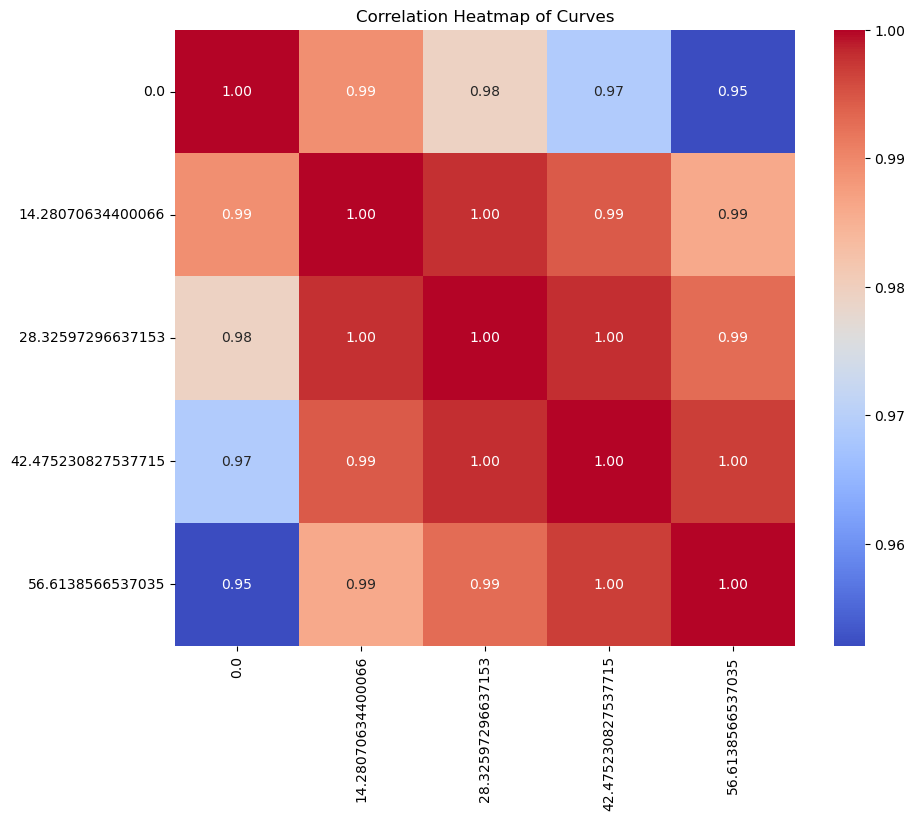

In [60]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[xi].corr(method="pearson"), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Curves")
plt.show()

shift=-4.93, scale=1.82, loss=1864796962.3416
shift=-2.10, scale=3.50, loss=7390344340.0152
shift=-3.48, scale=0.57, loss=4978428474.4769
shift=7.75, scale=4.03, loss=43950028358.9680
shift=-4.45, scale=3.73, loss=7171684762.2227
shift=0.86, scale=3.60, loss=10844390941.2319
shift=-5.86, scale=1.33, loss=3462298625.4548
shift=8.46, scale=3.26, loss=29012010912.1060
shift=-1.75, scale=0.75, loss=3004467630.1743
shift=-7.05, scale=0.79, loss=6885941914.1515
shift=1.71, scale=2.67, loss=3672953230.5555
shift=-8.78, scale=2.39, loss=4663841615.3833
shift=-1.29, scale=0.13, loss=6904759342.3390
shift=0.50, scale=2.01, loss=446942258.6182
shift=3.98, scale=2.27, loss=3325798605.2668
shift=7.29, scale=1.41, loss=1895760600.9362
shift=6.37, scale=2.94, loss=14773148867.6012
shift=-7.87, scale=0.30, loss=9732455386.3581
shift=9.15, scale=4.62, loss=73716192783.1536
shift=-9.41, scale=3.93, loss=6610860944.3565
shift=9.85, scale=0.95, loss=1516400095.1892
shift=2.56, scale=4.90, loss=34364924340

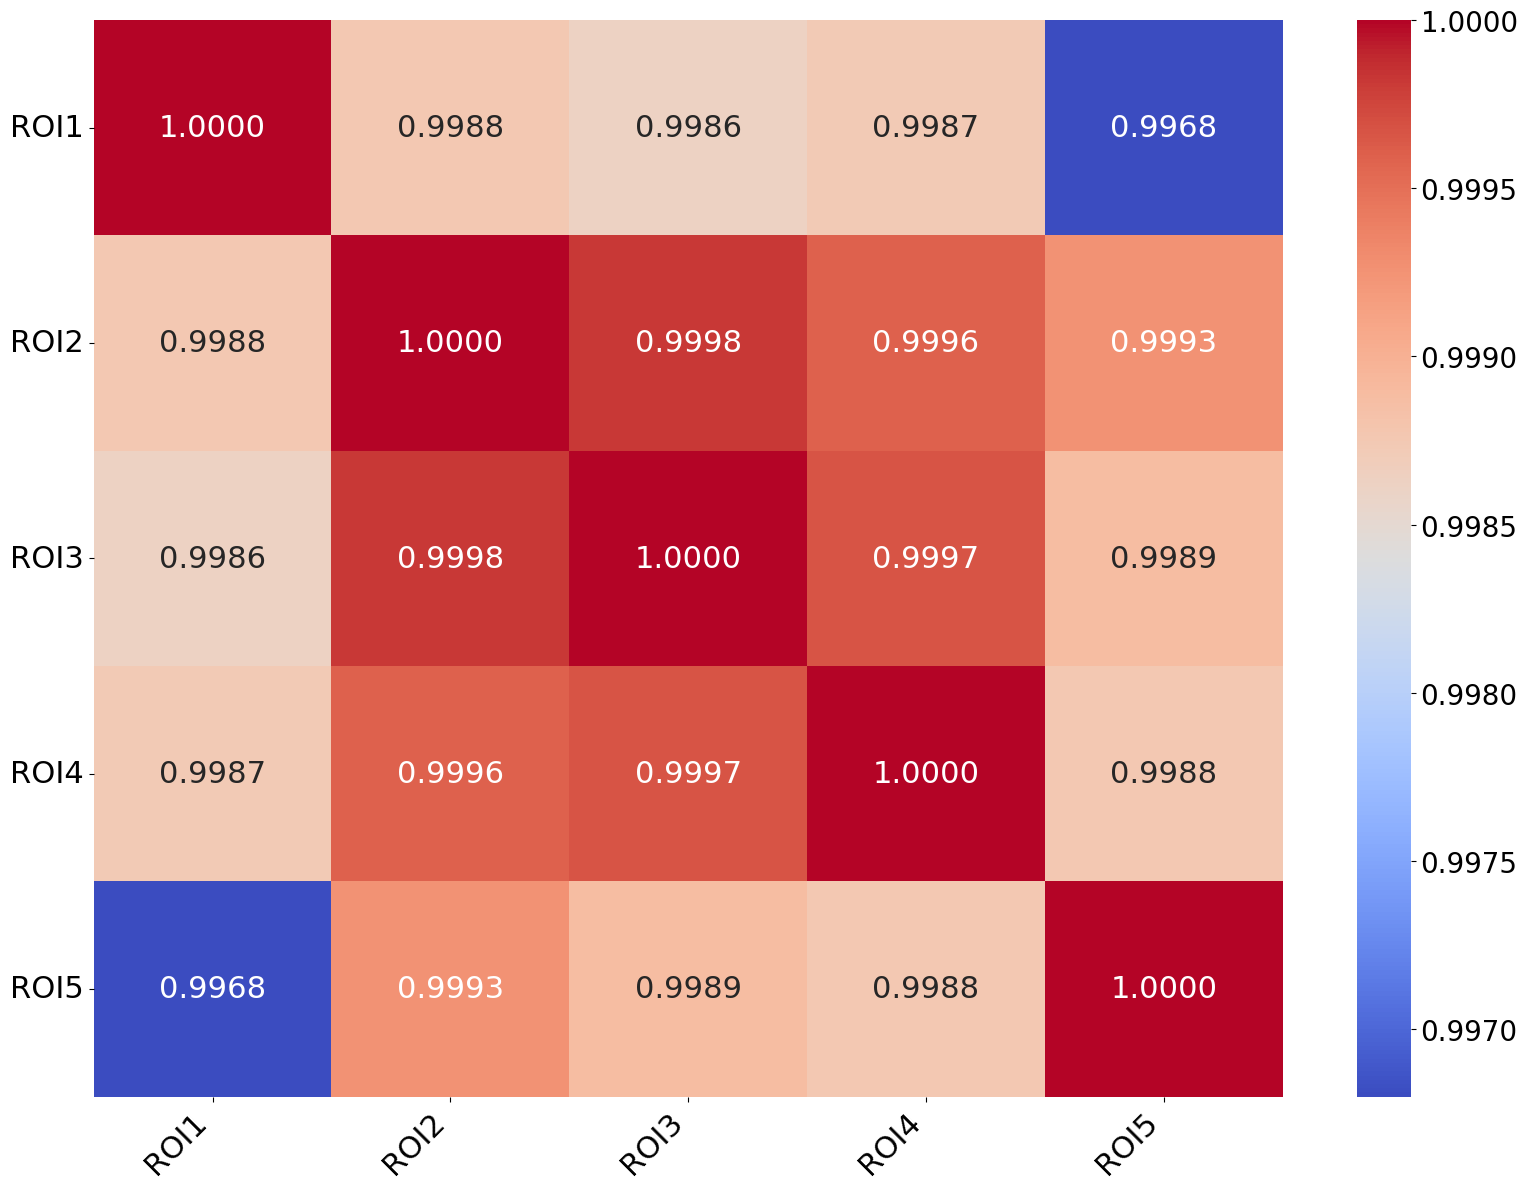

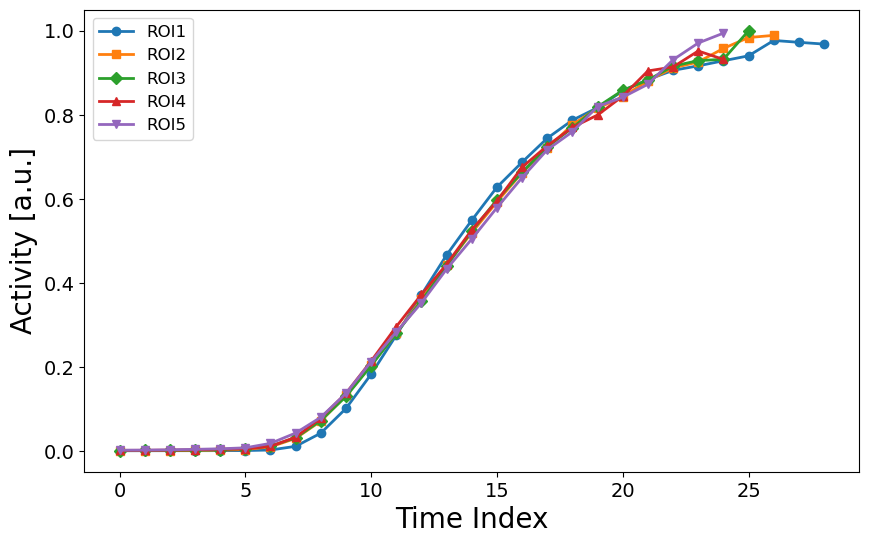

In [61]:
data = df

# ====================
# 📦 IMPORTS
# ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.interpolate import interp1d
from scipy.optimize import minimize, differential_evolution
from scipy.stats import pearsonr


# ====================
# 🧠 FUNCTION DEFINITIONS
# ====================

def shift_curve_interp(curve, shift, target_len):
    """
    Shift curve by a (possibly fractional) amount using interpolation.
    Fills out-of-bounds values with NaN.
    """
    x = np.arange(len(curve))
    interpolator = interp1d(x, curve, kind='linear', bounds_error=False, fill_value=np.nan)
    x_shifted = np.arange(target_len) + shift
    return interpolator(x_shifted)


def optimize_shift_and_scale(curve, reference, search_bounds=(-10, 10), scale_bounds=(0.1, 5.0), method='mse'):
    """
    Find optimal (time shift, amplitude scale) to align curve to reference.
    """

    def loss_fn(params):
        shift, scale = params
        shifted = shift_curve_interp(curve, shift, len(reference)) * scale

        valid = ~np.isnan(shifted) & ~np.isnan(reference)
        if np.sum(valid) < 2:
            print(f"Too few valid points for shift={shift:.2f}, scale={scale:.2f}")
            return np.inf

        residuals = (shifted - reference) ** 2
        weights = np.ones(len(reference))
        weights[:len(reference) // 2] *= 2.0
        weights = weights[valid]
        residuals = residuals[valid]

        weights /= np.sum(weights)
        loss = np.sum(weights * residuals)

        print(f"shift={shift:.2f}, scale={scale:.2f}, loss={loss:.4f}")
        return loss


    bounds = [search_bounds, scale_bounds]
    result = differential_evolution(loss_fn, bounds)
    return result.x  # (best_shift, best_scale)


# ====================
# 📊 DATA SELECTION
# ====================
# Replace xi[1:4] with your actual indices or column names
selected_cols = xi[0:9]
custom_names = [f"ROI{i+1}" for i in range(len(selected_cols))]

# ====================
# ⚙️ ALIGNMENT
# ====================
aligned_curves = {}
shifts = {}

# Use unscaled reference (first curve)
ref_curve = data[selected_cols[0]].to_numpy(dtype=float)
aligned_curves[custom_names[0]] = ref_curve
shifts[custom_names[0]] = (0.0, 1.0)

for name, col in zip(custom_names[1:], selected_cols[1:]):
    curve = data[col].to_numpy(dtype=float)

    opt_shift, opt_scale = optimize_shift_and_scale(curve, ref_curve)
    aligned = shift_curve_interp(curve, opt_shift, len(ref_curve)) * opt_scale

    aligned_curves[name] = aligned
    shifts[name] = (opt_shift, opt_scale)


aligned_data = pd.DataFrame(aligned_curves)
aligned_data = aligned_data / aligned_data.max().max()

# ====================
# 📈 PLOTS
# ====================


print("Optimal shifts (time, scale):")
for name, (shift, scale) in shifts.items():
    print(f"{name}: Δt = {shift:.2f}, scale = {scale:.3f}")
plt.figure(figsize=(16, 12))

# Compute correlation separately to reformat colorbar later
corr_matrix = aligned_data.corr(method="pearson", min_periods=4)

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    annot_kws={"size": 22},
    cbar_kws={"format": "%.4f"}  # Format colorbar to 4 decimal places
)

# Increase font size of tick labels
plt.xticks(fontsize=22, rotation=45, ha="right")
plt.yticks(fontsize=22, rotation=0)

# Resize colorbar label font and ticks
colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=20)

plt.title("", fontsize=20)
plt.tight_layout()

plt.savefig("poplar_exhange_pearson.pdf", format="pdf")  
plt.show()




markers = ['o', 's', 'D', '^', 'v', '>', '<', 'p', '*', 'h']  # Extend as needed
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(10, 6))
for i, col in enumerate(aligned_data.columns):
    plt.plot(
        aligned_data[col],
        label=col,
        linewidth=2,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        markevery=1,  # place marker every 10 points (adjust as needed)
        markersize=6
    )

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Time Index", fontsize=20)
plt.ylabel("Activity [a.u.]", fontsize=20)

plt.legend(fontsize=12)
plt.title("", fontsize=16)
#plt.ylim(0, 1)
plt.savefig("poplar_exhange_aligned.pdf", format="pdf")  
plt.show()


In [62]:
def plot_all_columns(data_array):
    """
    Function to plot all columns in a 2D array. Each column is stored 
    in a dynamically created variable named roi1, roi2, ..., roiN.

    Parameters:
    data_array (ndarray): 2D array where each column is a separate dataset to plot.
    """
    # Dictionary to hold dynamically created variables
    roi_dict = {}
    
    # Extract the first column and compute its maximum
    roi1_max = np.max(data_array[:, 0])
    
    # Loop through columns in the data array
    for i in range(data_array.shape[1]):
        # Dynamically name the variable
        var_name = f'roi{i+1}'
        roi_dict[var_name] = data_array[:, i] / roi1_max  # Normalize by roi1 max
        
        # Plot the normalized column
        plt.plot(roi_dict[var_name], label=var_name)
    
    # Add legend and labels
    plt.legend()
    plt.xlabel('Index')
    plt.ylabel('Normalized Value')
    plt.title('Normalized Plots of All Columns')
    plt.show()
    
    return roi_dict  # Return dictionary of normalized variables

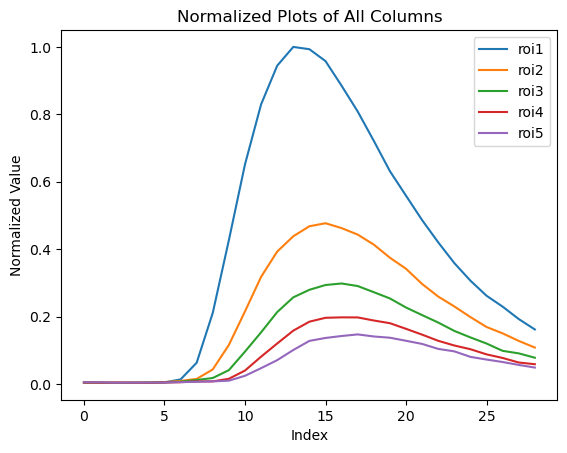

In [63]:
rois = plot_all_columns(data_unc[:,0:9])

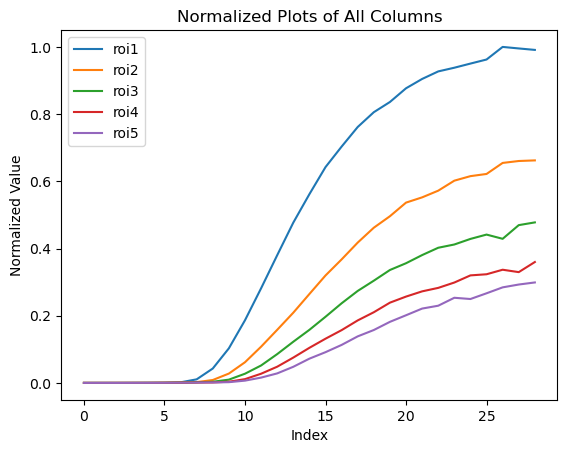

In [64]:
rois = plot_all_columns(data_cor[:,0:9])

In [65]:
xi=xi[0:9]

In [66]:
rois

{'roi1': array([2.01788113e-04, 2.18647145e-04, 2.80959994e-04, 3.07143590e-04,
        4.03083065e-04, 5.97370350e-04, 1.99251943e-03, 1.08775182e-02,
        4.30699031e-02, 1.03194642e-01, 1.86673799e-01, 2.81735471e-01,
        3.80175027e-01, 4.77227226e-01, 5.61850853e-01, 6.42405240e-01,
        7.03385876e-01, 7.61768531e-01, 8.05785043e-01, 8.36128460e-01,
        8.76923607e-01, 9.04698727e-01, 9.27132090e-01, 9.38121360e-01,
        9.50447222e-01, 9.62543646e-01, 1.00000000e+00, 9.95465228e-01,
        9.91126314e-01]),
 'roi2': array([2.27115728e-04, 2.15136115e-04, 2.81632320e-04, 2.92653613e-04,
        3.50851108e-04, 7.07038856e-04, 1.34363567e-03, 2.61096423e-03,
        8.85310215e-03, 2.80500950e-02, 6.17380905e-02, 1.08006520e-01,
        1.58185251e-01, 2.09201590e-01, 2.64784247e-01, 3.19899906e-01,
        3.67702724e-01, 4.17780418e-01, 4.62067999e-01, 4.96222030e-01,
        5.36743933e-01, 5.52340443e-01, 5.72287081e-01, 6.02034138e-01,
        6.15482810e-01

In [67]:
roi1 = rois['roi1']
roi2 = rois['roi2']
roi3 = rois['roi3']
roi4 = rois['roi4']
roi5 = rois['roi5']
# roi6 = rois['roi6']
# roi7 = rois['roi7']
# roi8 = rois['roi8']



In [68]:
def find_roots(x, y):
    s = np.abs(np.diff(np.sign(y))).astype(bool)
    return x[:-1][s] + np.diff(x)[s] / (np.abs(y[1:][s] / y[:-1][s]) + 1)

In [69]:
plt.rcParams['axes.prop_cycle'].by_key()['color']

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

In [70]:
def process_and_plot_rois(rois, t):
    """
    Processes and plots multiple ROIs from a dictionary using cubic spline interpolation and calculates max ratios.

    Parameters:
    - rois (dict): Dictionary where keys are ROI names (e.g., 'roi1', 'roi2') and values are 1D arrays of data.
    - t (array): Time array corresponding to the ROIs.

    Returns:
    - results (dict): Dictionary where keys are ROI names and values are a dictionary with:
        - 'cubic_spline': The cubic spline object for the ROI.
        - 'max_value': Maximum value of the interpolated data.
        - 'half_max': Half-maximum value of the interpolated data.
        - 'roots': Roots of the cubic spline.
        - 'ratios': List of ratios between consecutive max values (calculated for all ROIs together).
    """
    results = {}
    maxima = []
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    plt.figure()
    plt.style.use('default')
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    for i, (roi_name, roi_data) in enumerate(rois.items()):
        # Interpolate using Cubic Spline
        cu = interpolate.CubicSpline(t.ravel(), roi_data.ravel())
        x_interp = np.linspace(0, max(t), 500)
        y_interp = cu(x_interp)

        # Compute max and half-max
        max_value = np.max(y_interp)
        half_max = max_value / 2
        maxima.append(max_value)

        # Plot interpolated curve
        color = colors[i % len(colors)]
        plt.plot(x_interp, y_interp, 'k', linewidth=1.2, label="Spline")

        # Highlight max and half-max
        plt.hlines(max_value, -9, max(t)+10, linestyle=(0, (1, 1)), color=color, label="Maximum")
        plt.hlines(half_max, -9, max(t)+10, linestyle='--', color=color, label="Half-Maximum")

        # Plot the original points
        plt.plot(t, roi_data, marker='.', markersize=8, linestyle='none', color=color, label="Experimental Data")

        # Save results
        results[roi_name] = {
            'cubic_spline': cu,
            'max_value': max_value,
            'half_max': half_max,
            'roots': cu.roots()
        }
    
    # Compute ratios of maxima
    ratios = [maxima[i] / maxima[i + 1] for i in range(len(maxima) - 1)]

    # Add ratios to results
    results['ratios'] = ratios

    plt.xlabel("Time [min]", fontsize=16)
    plt.ylabel("Activity [a.u.]", fontsize=16)
    
    # Remove duplicate labels while keeping the first occurrence
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_labels = {}
    unique_handles = []

    for handle, label in zip(handles, labels):
        if label not in unique_labels:  # Keep first occurrence
            unique_labels[label] = handle
            unique_handles.append(handle)

    # Add legend with unique labels
    plt.legend(unique_handles, unique_labels.keys(), fontsize=10)
    
    plt.savefig("storage_change_hmax_a.pdf", format="pdf")  
    
    plt.show()
    
   
    
    return results

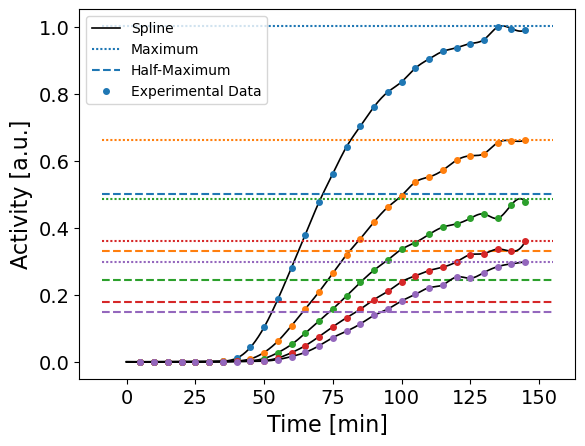

In [71]:
results=process_and_plot_rois(rois,t)

In [72]:
results['ratios']

[np.float64(1.514818844553241),
 np.float64(1.359188522910205),
 np.float64(1.353770754811352),
 np.float64(1.2032576606250869)]

In [73]:
def compute_hmax_times(results, time_range):
    """
    Computes the half-max times for each ROI in the results using the find_roots function.

    Parameters:
    - results (dict): Dictionary containing ROI results with cubic splines and half-max values.
    - time_range (array): Array of time values to use for interpolation (e.g., np.linspace).

    Returns:
    - hmax_times (dict): Dictionary with ROI names as keys and the first half-max time as values.
    """
    def find_roots(x, y):
        """
        Finds the roots of a signal crossing zero using interpolation.
        """
        s = np.abs(np.diff(np.sign(y))).astype(bool)
        return x[:-1][s] + np.diff(x)[s] / (np.abs(y[1:][s] / y[:-1][s]) + 1)

    hmax_times = {}

    for roi_name, data in results.items():
        if roi_name == "ratios":  # Skip the "ratios" key if present
            continue
        
        # Extract the cubic spline and half-max value
        cubic_spline = data['cubic_spline']
        half_max = data['half_max']
        
        # Evaluate the cubic spline minus the half-max value
        y_interp = cubic_spline(time_range) - half_max
        
        # Find roots
        roots = find_roots(time_range, y_interp)
        
        # Take the first root if any, otherwise assign NaN
        hmax_times[roi_name] = roots[0] if len(roots) > 0 else np.nan

    return hmax_times



In [74]:
hmaxi = np.array(list(compute_hmax_times(results,np.linspace(0,145,500)).values()))

In [75]:
hmaxi

array([71.3909808 , 81.13789605, 85.83128029, 88.86727482, 92.88923445])

In [76]:
points=np.array(xi[:], dtype="float")

In [77]:
points

array([ 0.        , 14.28070634, 28.32597297, 42.47523083, 56.61385665])

[   2.62659026 -192.35571585] 0.3745038274804596


np.float64(0.9425171394582815)

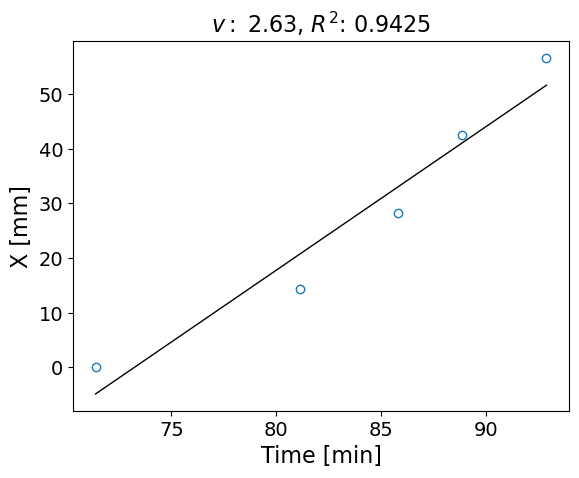

In [78]:
points=np.array(xi, dtype="float")

Iv=np.ones((len(hmaxi),1))
Mv=np.array(np.append(Iv,hmaxi.reshape(len(hmaxi),1),axis=1))


mbinter_v=np.array([]).reshape(0,3)
b1v, m1v = lstsq(Mv, points)[0]
mbinter_v = np.vstack((mbinter_v, (m1v, b1v, -b1v/m1v)))


plt.style.use('default')
    
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 


for i in range (0,len(mbinter_v)):
    plt.plot(hmaxi, mbinter_v[i][0]*np.array(hmaxi)+mbinter_v[i][1], label=np.round(mbinter_v[i][0],3),color='k', linewidth=1)    
    

    
#np.polyfit(intercepts,points,1)
plt.plot(hmaxi, points, marker='o', linestyle='None',markerfacecolor='none')
plt.savefig("storage_change_hmax_b.pdf", format="pdf")  


plt.xlabel("Time [min]",fontsize=16)
plt.ylabel("X [mm]",fontsize=16)
plt.title(f"$v:$ {np.around(mbinter_v[0][0],2)}, $R^2$: {np.around(np.corrcoef(hmaxi, points)[0,1]**2, 4)}", fontsize=16)
np.corrcoef(hmaxi, points)[0,1]**2

plt.savefig("storage_change_hmax_b.pdf", format="pdf")  

fit, V=np.polyfit(hmaxi,points,1, cov=True)
print(fit,np.sqrt(V[0][0]))

np.corrcoef(hmaxi, points)[0,1]**2


In [79]:
np.sqrt(V[0][0])/np.around(mbinter_v[0][0],2)*100

np.float64(14.239689257812152)